# Decision Tree Baseline (SLM Feature-Engineered Dataset)

**Goal:** Train and evaluate a Decision Tree baseline model to predict `is_fraud` using `feature_engineered_with_SLM.csv`.

This notebook:
- loads the SLM feature-engineered dataset
- builds a preprocessing + Decision Tree pipeline
- evaluates baseline performance (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)
- lightly tunes / prunes the tree to reduce overfitting
- exports plots + a metrics row for your team comparison table

In [1]:
# === 1) Imports + settings ===
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

RANDOM_SEED = 42

# Update these paths to match your repo structure
DATA_PATH = r"../data/processed/feature_engineered_with_SLM.csv"

OUTPUT_DIR = "../outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

pd.set_option("display.max_columns", 200)

## 2) Load data + quick sanity checks

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(3))

# Target distribution (important for fraud imbalance)
target_col = "is_fraud"
print("\nTarget distribution:")
display(df[target_col].value_counts(dropna=False).to_frame("count"))
print("Positive rate:", df[target_col].mean())

# Missingness overview (top 15)
missing = df.isna().mean().sort_values(ascending=False)
display(missing.head(15).to_frame("missing_fraction"))

Shape: (1200, 33)


,transaction_id,customer_id,transaction_datetime,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,is_fraud,transaction_note,slm_risk_score,slm_urgency,slm_anomaly_category,txn_hour,txn_dayofweek,txn_week,is_weekend,is_night,prev_txn_time,txn_gap_minutes,txn_7d_count,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,998,1000,2022-10-05 15:13:00,US,mobile_app,luxury,672.47,23.0,2,3,0,new device,9,high,fraud,15,2,40,0,0,NaN,-1.000000,NaN,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,953,1000,2023-02-05 06:18:18,US,web,gaming,2593.31,84.0,0,0,1,overnight shipping,8,high,fraud,6,6,5,1,0,2022-10-05 15:13:00,176585.300000,NaN,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,94,1000,2023-03-23 18:04:02,US,pos_terminal,electronics,302.22,70.0,3,1,0,high value item,9,high,fraud,18,3,12,0,0,2023-02-05 06:18:18,66945.733333,NaN,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2



Target distribution:


,count
is_fraud,
0,1119
1,81


Positive rate: 0.0675


,missing_fraction
txn_7d_count,1.000000
prev_txn_time,0.149167
amount_z_customer,0.000833
customer_std_amount,0.000833
transaction_id,0.000000
txn_week,0.000000
composite_risk_score,0.000000
high_amount_z,0.000000
low_device_trust,0.000000
is_risky_country,0.000000


## 3) Define features (avoid leakage)

In [3]:
# Columns that should NOT be used as features:
DROP_COLS = [
    "transaction_id", "customer_id",          # identifiers
    "transaction_datetime", "prev_txn_time",  # raw timestamps (you already engineered time features)
    "transaction_note",                       # raw text (you already extracted SLM features)
    "txn_7d_count"                            # appears fully missing in this dataset
]

existing_drop = [c for c in DROP_COLS if c in df.columns]
print("Dropping:", existing_drop)

X = df.drop(columns=[target_col] + existing_drop, errors="ignore")
y = df[target_col].astype(int)

# Identify column types
categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

display(X.head(3))

Dropping: ['transaction_id', 'customer_id', 'transaction_datetime', 'prev_txn_time', 'transaction_note', 'txn_7d_count']

Categorical columns: ['country', 'channel', 'merchant_category', 'slm_urgency', 'slm_anomaly_category']
Numeric columns: ['amount', 'device_trust_score', 'num_txn_24h_customer', 'previous_chargeback_count', 'slm_risk_score', 'txn_hour', 'txn_dayofweek', 'txn_week', 'is_weekend', 'is_night', 'txn_gap_minutes', 'txn_hour_count', 'txn_dayofweek_count', 'customer_mean_amount', 'customer_std_amount', 'amount_z_customer', 'is_risky_country', 'low_device_trust', 'high_amount_z', 'composite_risk_score', 'urgency_numeric']


,country,channel,merchant_category,amount,device_trust_score,num_txn_24h_customer,previous_chargeback_count,slm_risk_score,slm_urgency,slm_anomaly_category,txn_hour,txn_dayofweek,txn_week,is_weekend,is_night,txn_gap_minutes,txn_hour_count,txn_dayofweek_count,customer_mean_amount,customer_std_amount,amount_z_customer,is_risky_country,low_device_trust,high_amount_z,composite_risk_score,urgency_numeric
0,US,mobile_app,luxury,672.47,23.0,2,3,9,high,fraud,15,2,40,0,0,-1.000000,1,2,1931.283333,1662.07937,-0.757373,0,1,0,7.333333,2
1,US,web,gaming,2593.31,84.0,0,0,8,high,fraud,6,6,5,1,0,176585.300000,1,2,1931.283333,1662.07937,0.398312,0,0,0,3.555556,2
2,US,pos_terminal,electronics,302.22,70.0,3,1,9,high,fraud,18,3,12,0,0,66945.733333,1,2,1931.283333,1662.07937,-0.980136,0,0,0,4.000000,2


## 4) Train-test split (stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train positive rate:", y_train.mean(), " Test positive rate:", y_test.mean())

Train size: (960, 26)  Test size: (240, 26)
Train positive rate: 0.06770833333333333  Test positive rate: 0.06666666666666667


## 5) Preprocess + baseline Decision Tree pipeline

In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

dt_baseline = DecisionTreeClassifier(
    random_state=RANDOM_SEED,
    class_weight="balanced"  # helpful for imbalanced fraud labels
)

baseline_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", dt_baseline)
])

## 6) Train + evaluate baseline

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,DecisionTree_baseline,0.870833,0.058824,0.0625,0.060606,0.495536,0.066176



Classification report:
              precision    recall  f1-score   support

           0     0.9327    0.9286    0.9306       224
           1     0.0588    0.0625    0.0606        16

    accuracy                         0.8708       240
   macro avg     0.4958    0.4955    0.4956       240
weighted avg     0.8745    0.8708    0.8726       240

Confusion matrix:
 [[208  16]
 [ 15   1]]


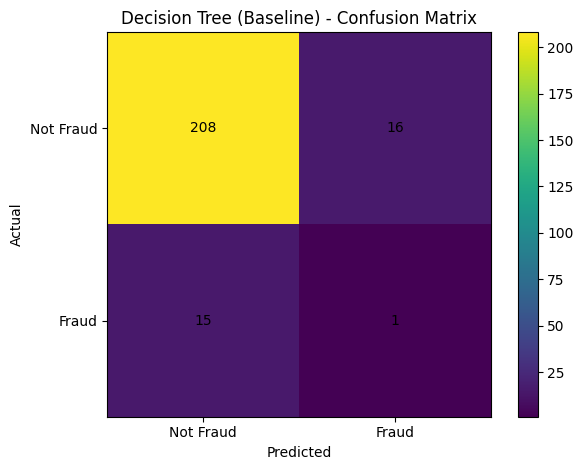

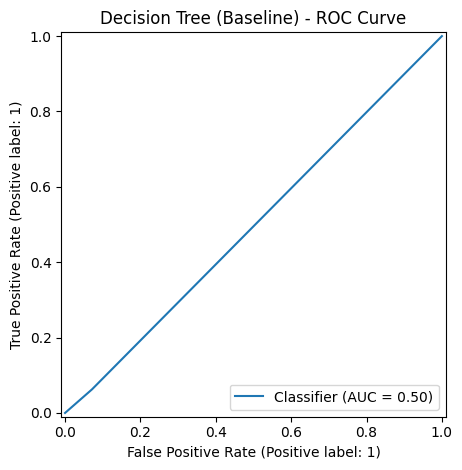

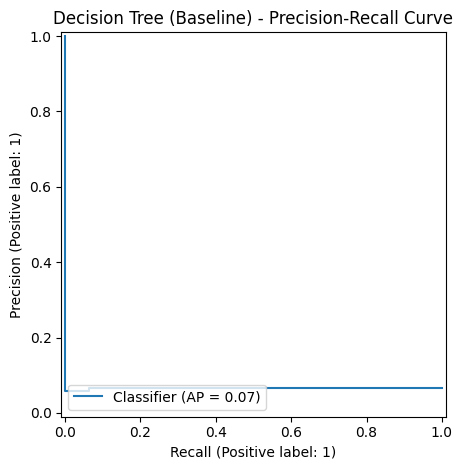

In [6]:
baseline_pipe.fit(X_train, y_train)

# Predictions
y_pred = baseline_pipe.predict(X_test)

# Probabilities for ROC-AUC / PR-AUC
y_proba = baseline_pipe.predict_proba(X_test)[:, 1]

metrics = {
    "model": "DecisionTree_baseline",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
}

display(pd.DataFrame([metrics]))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Decision Tree (Baseline) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_baseline_confusion_matrix.png"), dpi=200)
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Decision Tree (Baseline) - ROC Curve")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_baseline_roc_curve.png"), dpi=200)
plt.show()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Decision Tree (Baseline) - Precision-Recall Curve")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_baseline_pr_curve.png"), dpi=200)
plt.show()

## 7) Light tuning (reduce overfitting)

In [7]:
# Small search space (keeps it fast + explainable)
param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__min_samples_split": [2, 10, 20],
    # Cost-complexity pruning (optional but useful): try a few values
    "model__ccp_alpha": [0.0, 1e-4, 5e-4, 1e-3],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid = GridSearchCV(
    estimator=baseline_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best params: {'model__ccp_alpha': 0.0, 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV F1: 0.1318254119835826


## 8) Evaluate tuned tree

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,DecisionTree_tuned,0.579167,0.052632,0.3125,0.09009,0.462751,0.062367



Classification report (tuned):
              precision    recall  f1-score   support

           0     0.9241    0.5982    0.7263       224
           1     0.0526    0.3125    0.0901        16

    accuracy                         0.5792       240
   macro avg     0.4884    0.4554    0.4082       240
weighted avg     0.8660    0.5792    0.6839       240



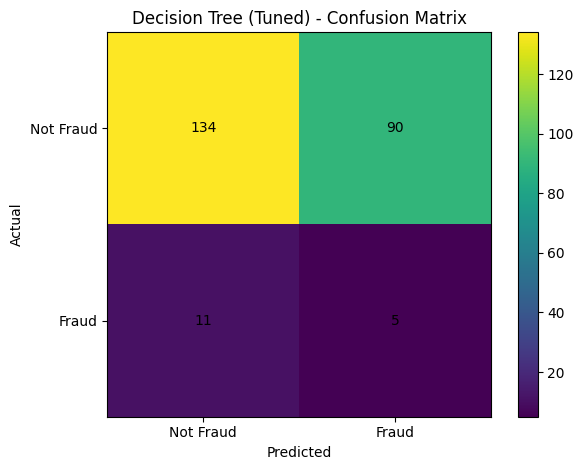

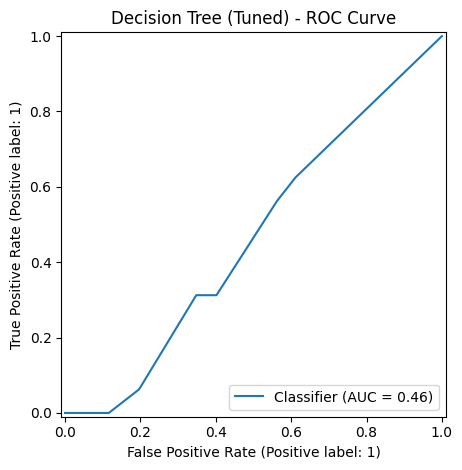

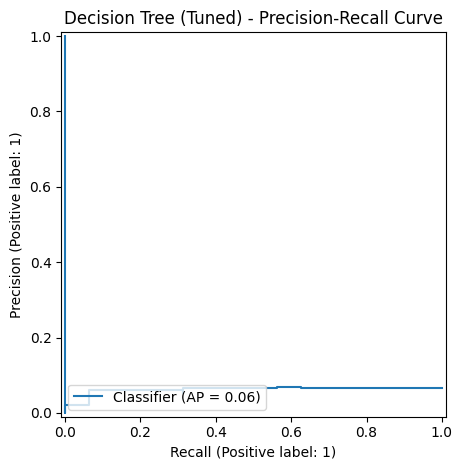

In [8]:
best_pipe = grid.best_estimator_

y_pred_tuned = best_pipe.predict(X_test)
y_proba_tuned = best_pipe.predict_proba(X_test)[:, 1]

metrics_tuned = {
    "model": "DecisionTree_tuned",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_tuned),
    "pr_auc": average_precision_score(y_test, y_proba_tuned),
}
display(pd.DataFrame([metrics_tuned]))

print("\nClassification report (tuned):")
print(classification_report(y_test, y_pred_tuned, digits=4))

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred_tuned)

plt.figure()
plt.imshow(cm2)
plt.title("Decision Tree (Tuned) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])
for (i, j), val in np.ndenumerate(cm2):
    plt.text(j, i, int(val), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_tuned_confusion_matrix.png"), dpi=200)
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("Decision Tree (Tuned) - ROC Curve")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_tuned_roc_curve.png"), dpi=200)
plt.show()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("Decision Tree (Tuned) - Precision-Recall Curve")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_tuned_pr_curve.png"), dpi=200)
plt.show()

## 9) Feature importance (interpretable baseline)

,feature,importance
1,device_trust_score,2.362285e-01
0,amount,1.829184e-01
5,txn_hour,1.005276e-01
32,merchant_category_electronics,9.653140e-02
23,country_DE,8.266128e-02
15,amount_z_customer,8.036129e-02
22,country_CN,6.310832e-02
35,merchant_category_luxury,5.704888e-02
31,channel_web,5.633473e-02
6,txn_dayofweek,3.845530e-02


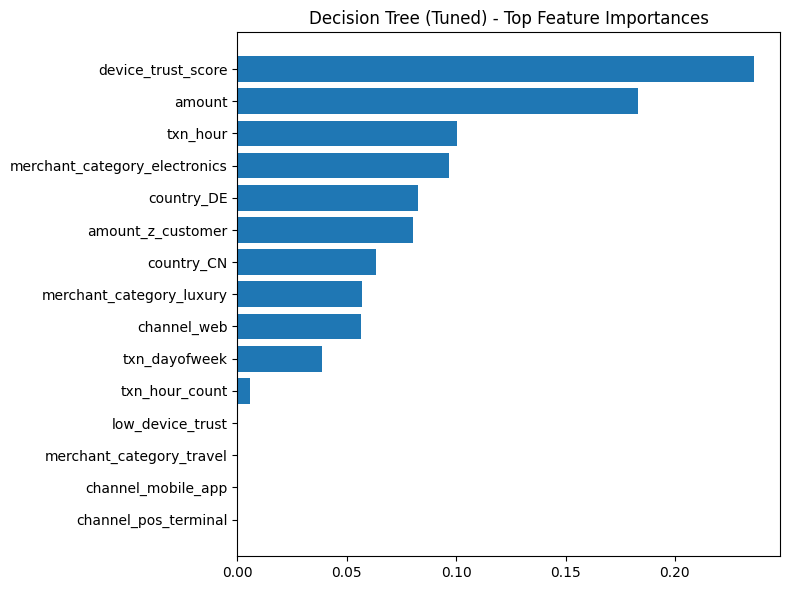

Tree depth: 5
Number of leaves: 18


In [9]:
# Helper: get feature names after ColumnTransformer (incl. one-hot)
def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    feature_names = []

    # numeric
    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_cols)

    # categorical (one-hot)
    if "cat" in preprocessor.named_transformers_:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(ohe_names)

    return feature_names

pre = best_pipe.named_steps["preprocess"]
model = best_pipe.named_steps["model"]

feat_names = get_feature_names(pre)
importances = model.feature_importances_

fi = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
      .sort_values("importance", ascending=False)
)

display(fi.head(15))

# Plot top 15
topk = 15
plt.figure(figsize=(8, 6))
plt.barh(fi.head(topk)["feature"][::-1], fi.head(topk)["importance"][::-1])
plt.title("Decision Tree (Tuned) - Top Feature Importances")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "dt_tuned_feature_importance_top15.png"), dpi=200)
plt.show()

print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

# Save feature importances table
fi.to_csv(os.path.join(TAB_DIR, "dt_feature_importance.csv"), index=False)

## 10) Export metrics row for team comparison table

In [10]:
all_metrics = pd.DataFrame([metrics, metrics_tuned])
display(all_metrics)

all_metrics.to_csv(os.path.join(TAB_DIR, "dt_metrics.csv"), index=False)
print("Saved:", os.path.join(TAB_DIR, "dt_metrics.csv"))
print("Figures saved in:", FIG_DIR)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,DecisionTree_baseline,0.870833,0.058824,0.0625,0.060606,0.495536,0.066176
1,DecisionTree_tuned,0.579167,0.052632,0.3125,0.090090,0.462751,0.062367


Saved: ../outputs/tables/dt_metrics.csv
Figures saved in: ../outputs/figures
